In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from lightgbm import LGBMClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    precision_recall_curve
)

In [2]:
df = pd.read_csv("../data/model_ready_dataset.csv")

df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TWF,HDF,PWF,OSF,...,timestamp,Ambient_Temperature,Load_Density,Humidity,Shift,Day_Type,temp_diff,load_ratio,humidity_impact,Machine failure
0,2,298.1,308.6,1551,42.8,0,0,0,0,0,...,2025-01-01 00:00:00,26,62,41,0,0,10.5,0.62,25.42,0
1,1,298.2,308.7,1408,46.3,3,0,0,0,0,...,2025-01-01 00:01:00,39,34,47,1,1,10.5,0.34,15.98,0
2,1,298.1,308.5,1498,49.4,5,0,0,0,0,...,2025-01-01 00:02:00,34,43,81,0,0,10.4,0.43,34.83,0
3,1,298.2,308.6,1433,39.5,7,0,0,0,0,...,2025-01-01 00:03:00,30,97,46,0,1,10.4,0.97,44.62,0
4,1,298.2,308.7,1408,40.0,9,0,0,0,0,...,2025-01-01 00:04:00,27,76,49,1,0,10.5,0.76,37.24,0


In [3]:
df.columns

Index(['Type', 'Air temperature [K]', 'Process temperature [K]',
       'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF',
       'HDF', 'PWF', 'OSF', 'RNF', 'timestamp', 'Ambient_Temperature',
       'Load_Density', 'Humidity', 'Shift', 'Day_Type', 'temp_diff',
       'load_ratio', 'humidity_impact', 'Machine failure'],
      dtype='str')

In [4]:
X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]

In [5]:
print(X.dtypes)

Type                         int64
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
timestamp                      str
Ambient_Temperature          int64
Load_Density                 int64
Humidity                     int64
Shift                        int64
Day_Type                     int64
temp_diff                  float64
load_ratio                 float64
humidity_impact            float64
dtype: object


In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [7]:
print(df["timestamp"].head())

0    2025-01-01 00:00:00
1    2025-01-01 00:01:00
2    2025-01-01 00:02:00
3    2025-01-01 00:03:00
4    2025-01-01 00:04:00
Name: timestamp, dtype: str


In [8]:
df["timestamp"] = pd.to_datetime(df["timestamp"])

df["timestamp"] = df["timestamp"].astype("int64") // 10**9

In [9]:
df["timestamp"] = pd.to_datetime(df["timestamp"])
df["timestamp"] = df["timestamp"].astype("int64") // 10**9

In [10]:
X = df.drop("Machine failure", axis=1)
y = df["Machine failure"]

In [11]:
print(X.dtypes)

Type                         int64
Air temperature [K]        float64
Process temperature [K]    float64
Rotational speed [rpm]       int64
Torque [Nm]                float64
Tool wear [min]              int64
TWF                          int64
HDF                          int64
PWF                          int64
OSF                          int64
RNF                          int64
timestamp                    int64
Ambient_Temperature          int64
Load_Density                 int64
Humidity                     int64
Shift                        int64
Day_Type                     int64
temp_diff                  float64
load_ratio                 float64
humidity_impact            float64
dtype: object


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [14]:
print(X.columns.tolist())

['Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'timestamp', 'Ambient_Temperature', 'Load_Density', 'Humidity', 'Shift', 'Day_Type', 'temp_diff', 'load_ratio', 'humidity_impact']


In [15]:
import re

X.columns = [
    re.sub(r'[^A-Za-z0-9_]', '_', col)
    for col in X.columns
]

print(X.columns.tolist())

['Type', 'Air_temperature__K_', 'Process_temperature__K_', 'Rotational_speed__rpm_', 'Torque__Nm_', 'Tool_wear__min_', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF', 'timestamp', 'Ambient_Temperature', 'Load_Density', 'Humidity', 'Shift', 'Day_Type', 'temp_diff', 'load_ratio', 'humidity_impact']


In [16]:
print(X.columns.duplicated().sum())

0


In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [18]:
model = LGBMClassifier(random_state=42)
model.fit(X_train, y_train)

[LightGBM] [Info] Number of positive: 271, number of negative: 7729
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001362 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1494
[LightGBM] [Info] Number of data points in the train set: 8000, number of used features: 18
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.033875 -> initscore=-3.350616
[LightGBM] [Info] Start training from score -3.350616
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [19]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

pred = model.predict(X_test)
prob = model.predict_proba(X_test)[:, 1]

print("Accuracy :", accuracy_score(y_test, pred))
print("Precision:", precision_score(y_test, pred))
print("Recall   :", recall_score(y_test, pred))
print("F1 Score :", f1_score(y_test, pred))
print("ROC-AUC  :", roc_auc_score(y_test, prob))

Accuracy : 0.999
Precision: 1.0
Recall   : 0.9705882352941176
F1 Score : 0.9850746268656716
ROC-AUC  : 0.990108543417367


In [20]:
import os
os.makedirs("../model", exist_ok=True)

In [21]:
import joblib

joblib.dump(model, "../model/model.pkl")

['../model/model.pkl']

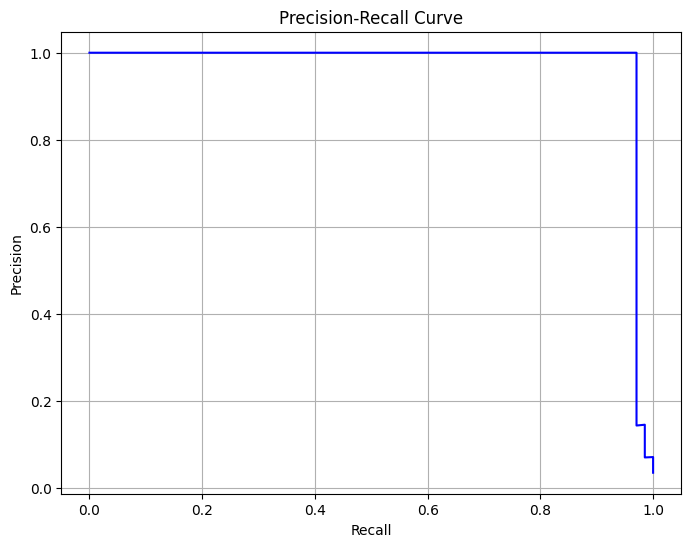

In [22]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, thresholds = precision_recall_curve(y_test, prob)

plt.figure(figsize=(8,6))
plt.plot(recall, precision, color="blue")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)
plt.show()

In [23]:
os.makedirs("../reports/plots", exist_ok=True)

plt.figure(figsize=(8,6))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid(True)

plt.savefig("../reports/plots/precision_recall_curve.png")
plt.close()